# Arigoni et al. (Scientific Data, 2024)

Seven lung-cancer cell lines measured together with 10x Chromium Next GEM 3' v3.1 and CellPlex. This notebook keeps the author-provided, confidently assigned CellPlex sample matrices, applies only the requested minimal filtering, and runs the mitochondrial-pattern and TIDYI analyses across all seven cell lines.

The PBMC sample is retained in the downloaded raw-data directory but is not part of this cancer-cell-line analysis.

In [1]:
from pathlib import Path
import warnings

import numba

_numba_njit = numba.njit
def njit_without_disk_cache(*args, **kwargs):
    kwargs["cache"] = False
    return _numba_njit(*args, **kwargs)

numba.njit = njit_without_disk_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from tidyi import tidy_rates
from threadpoolctl import threadpool_limits

sns.set_theme(style="whitegrid", context="notebook")
sc.settings.verbosity = 2

## Load the seven cancer cell lines

The first column of each 10x `features.tsv.gz` is used as `var_names`, so TIDYI receives the original Ensembl IDs directly. Gene symbols remain available in `adata.var['gene_symbols']`.

In [2]:
DATA_DIR = Path("/srv/mfs/hausserlab/data/ARigoni_Scidata_2024/BE1run12")
OUTPUT_DIR = Path("/scratch/chenxi.sun/RA project/cancer pattern/output/Arigoni_Scidata_2024")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_metadata = pd.DataFrame(
    {
        "sample_id": [
            "A549", "CCL-185-IG", "CRL5868", "DV90",
            "HCC78", "HTB178", "PC9",
        ],
        "cell_line": [
            "A549", "CCL-185-IG", "CRL5868", "DV90",
            "HCC78", "HTB178", "PC9",
        ],
    }
).set_index("sample_id")
cell_line_order = sample_metadata["cell_line"].tolist()

adatas = []
for sample_id, metadata in sample_metadata.iterrows():
    sample = sc.read_10x_mtx(
        DATA_DIR / sample_id,
        var_names="gene_ids",
        make_unique=True,
    )
    sample.obs["sample_id"] = sample_id
    sample.obs["cell_line"] = metadata["cell_line"]
    sample.obs["dataset_id"] = "BE1run12"
    adatas.append(sample)

adata = sc.concat(adatas, join="inner", merge="same", index_unique=None)
adata.obs["cell_line"] = pd.Categorical(
    adata.obs["cell_line"], categories=cell_line_order, ordered=True
)
adata.layers["counts"] = adata.X.copy()
assert adata.obs_names.is_unique
assert adata.var_names.str.startswith("ENSG").mean() > 0.95

raw_cell_counts = (
    adata.obs.groupby(["sample_id", "cell_line"], observed=True)
    .size()
    .rename("n_raw_cells")
    .reset_index()
)
display(sample_metadata)
display(raw_cell_counts)
display(
    pd.Series(
        {
            "n_cells": adata.n_obs,
            "n_genes": adata.n_vars,
            "Ensembl_ID_fraction": adata.var_names.str.startswith("ENSG").mean(),
        },
        name="loaded data",
    )
)
adata.var.head()

,cell_line
sample_id,
A549,A549
CCL-185-IG,CCL-185-IG
CRL5868,CRL5868
DV90,DV90
HCC78,HCC78
HTB178,HTB178
PC9,PC9


,sample_id,cell_line,n_raw_cells
0,A549,A549,6898
1,CCL-185-IG,CCL-185-IG,6354
2,CRL5868,CRL5868,2673
3,DV90,DV90,2998
4,HCC78,HCC78,2748
5,HTB178,HTB178,2965
6,PC9,PC9,4492


n_cells                29128.0
n_genes                36601.0
Ensembl_ID_fraction        1.0
Name: loaded data, dtype: float64

,gene_symbols,feature_types
ENSG00000243485,MIR1302-2HG,Gene Expression
ENSG00000237613,FAM138A,Gene Expression
ENSG00000186092,OR4F5,Gene Expression
ENSG00000238009,AL627309.1,Gene Expression
ENSG00000239945,AL627309.3,Gene Expression


In [3]:
adata.obs

,sample_id,cell_line,dataset_id
AAACCCAAGCCTATCA-1_A549,A549,A549,BE1run12
AAACCCAAGCGAGAAA-1_A549,A549,A549,BE1run12
AAACCCAAGTCTAGAA-1_A549,A549,A549,BE1run12
AAACCCACATCGAAGG-1_A549,A549,A549,BE1run12
AAACCCAGTCAAGCGA-1_A549,A549,A549,BE1run12
...,...,...,...
TTTGTTGAGCACTAAA-1_PC9,PC9,PC9,BE1run12
TTTGTTGGTCCTGTCT-1_PC9,PC9,PC9,BE1run12
TTTGTTGGTGGCAGAT-1_PC9,PC9,PC9,BE1run12
TTTGTTGTCAGTAGGG-1_PC9,PC9,PC9,BE1run12


## CellPlex assignment and droplet doublets

Cell Ranger assigned 29,606 barcodes to exactly one of eight CellPlex samples (29,128 cancer cells plus 478 PBMCs). The per-sample matrices loaded above contain those assigned barcodes. CellPlex multiplets and unassigned barcodes are therefore already absent; running Scrublet here would impose a second, expression-based filter and would conflict with the requested minimal filtering. Homotypic doublets that CellPlex cannot distinguish may remain.

In [4]:
metrics = pd.read_csv(DATA_DIR / "CRL5868" / "metrics_summary.csv")
assignment_metrics = [
    "Estimated number of cells",
    "Cell-associated barcodes identified as multiplets",
    "Cell-associated barcodes not assigned any CMOs",
    "Cells assigned to a sample",
]
cellplex_summary = metrics.loc[
    metrics["Library Type"].eq("Gene Expression")
    & metrics["Grouped By"].eq("Physical library ID")
    & metrics["Group Name"].eq("GEX_1")
    & metrics["Metric Name"].isin(assignment_metrics),
    ["Metric Name", "Metric Value"],
].drop_duplicates("Metric Name")
cellplex_summary

,Metric Name,Metric Value
13,Cell-associated barcodes identified as multiplets,"1,783 (3.79%)"
14,Cell-associated barcodes not assigned any CMOs,"15,606 (33.21%)"
39,Cells assigned to a sample,"29,606 (63.00%)"
47,Estimated number of cells,"46,995"


## Minimal QC

Only the requested filters are applied: cells must contain at least 100 detected genes, and genes must be detected in at least 3 retained cells. No mitochondrial, UMI, stress-state, or author-style stringent cutoff is applied.

In [5]:
n_cells_before_qc = adata.n_obs
n_genes_before_qc = adata.n_vars

adata.var["mt"] = (
    adata.var["gene_symbols"].astype(str).str.upper().str.startswith("MT-")
)
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

qc_cell_counts = (
    adata.obs.groupby(["sample_id", "cell_line"], observed=True)
    .size()
    .rename("n_after_minimal_qc")
    .reset_index()
)
qc_cell_counts = raw_cell_counts.merge(
    qc_cell_counts, on=["sample_id", "cell_line"], how="left"
)
qc_cell_counts["n_removed"] = (
    qc_cell_counts["n_raw_cells"] - qc_cell_counts["n_after_minimal_qc"]
)
display(qc_cell_counts)
display(
    pd.Series(
        {
            "cells_before": n_cells_before_qc,
            "cells_after": adata.n_obs,
            "cells_removed": n_cells_before_qc - adata.n_obs,
            "genes_before": n_genes_before_qc,
            "genes_after": adata.n_vars,
        },
        name="minimal QC",
    )
)
adata

,sample_id,cell_line,n_raw_cells,n_after_minimal_qc,n_removed
0,A549,A549,6898,6898,0
1,CCL-185-IG,CCL-185-IG,6354,6354,0
2,CRL5868,CRL5868,2673,2666,7
3,DV90,DV90,2998,2998,0
4,HCC78,HCC78,2748,2748,0
5,HTB178,HTB178,2965,2965,0
6,PC9,PC9,4492,4492,0


cells_before     29128
cells_after      29121
cells_removed        7
genes_before     36601
genes_after      29066
Name: minimal QC, dtype: int64

AnnData object with n_obs × n_vars = 29121 × 29066
    obs: 'sample_id', 'cell_line', 'dataset_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_symbols', 'feature_types', 'mt', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'

## UMI–mitochondrial pattern

Every retained cell is shown. Panels share both axes so that distributions can be compared directly across cell lines.

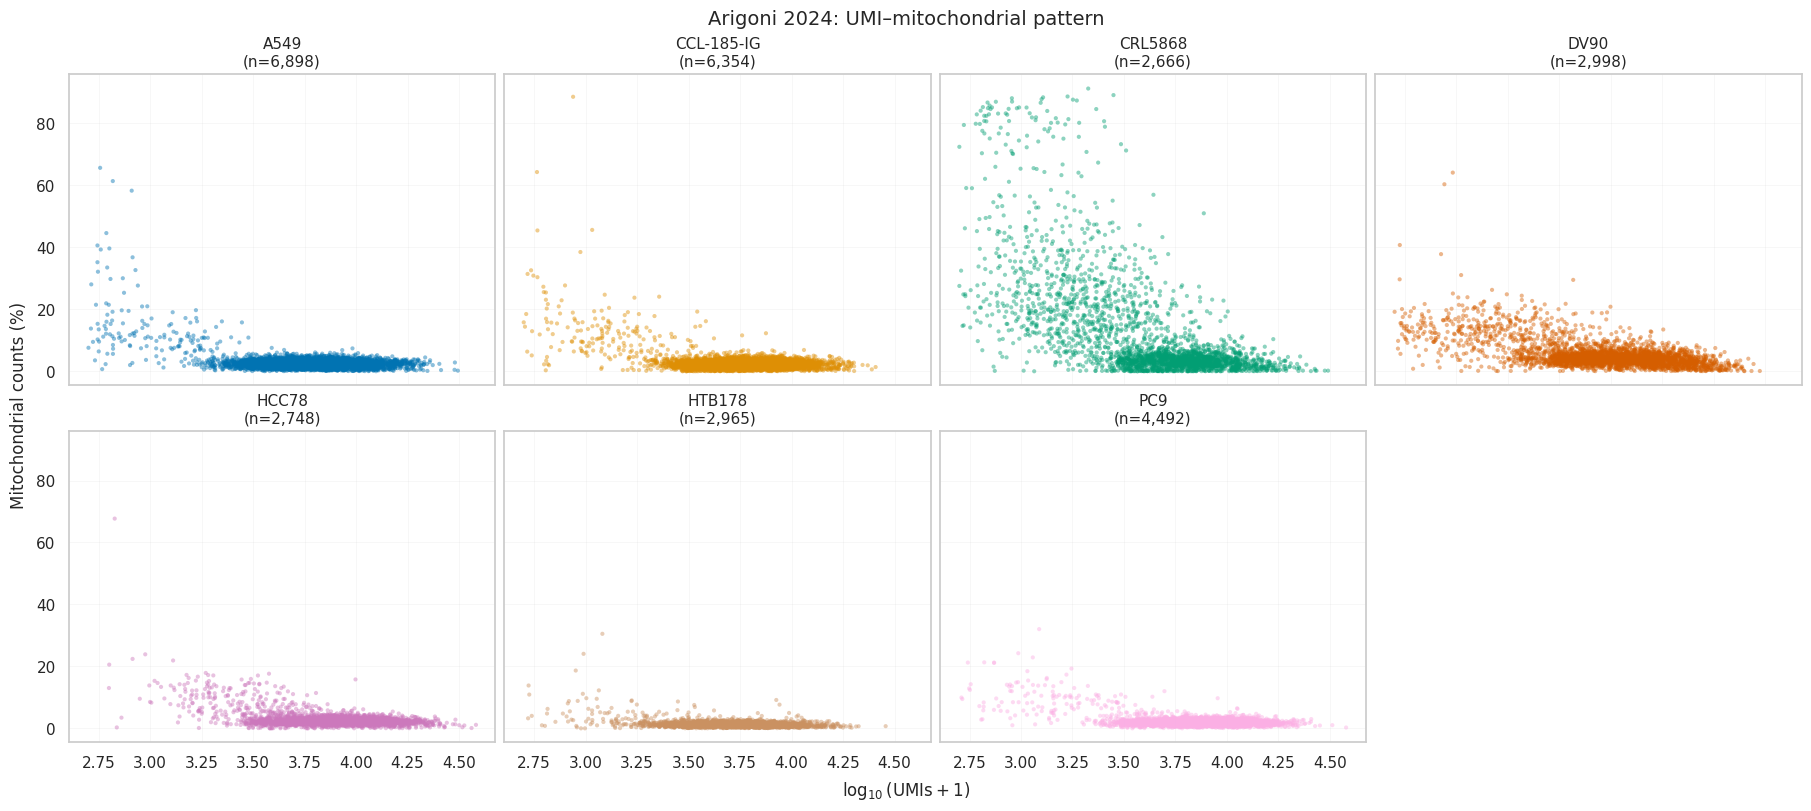

In [6]:
cell_line_palette = dict(
    zip(cell_line_order, sns.color_palette("colorblind", len(cell_line_order)))
)
plot_df = adata.obs[["cell_line", "total_counts", "pct_counts_mt"]].copy()
plot_df["log10_UMIs"] = np.log10(plot_df["total_counts"] + 1)

fig, axes = plt.subplots(
    2, 4, figsize=(18, 8), sharex=True, sharey=True, constrained_layout=True
)
for ax, cell_line in zip(axes.flat, cell_line_order):
    cell_line_df = plot_df[plot_df["cell_line"].eq(cell_line)]
    ax.scatter(
        cell_line_df["log10_UMIs"],
        cell_line_df["pct_counts_mt"],
        s=9, alpha=0.45, color=cell_line_palette[cell_line],
        edgecolors="none", rasterized=True,
    )
    ax.set_title(f"{cell_line}\n(n={len(cell_line_df):,})", fontsize=11)
    ax.grid(True, alpha=0.2, linewidth=0.5)

axes.flat[-1].set_visible(False)
fig.supxlabel(r"$\log_{10}(\mathrm{UMIs}+1)$", fontsize=12)
fig.supylabel("Mitochondrial counts (%)", fontsize=12)
fig.suptitle("Arigoni 2024: UMI–mitochondrial pattern", fontsize=14)
plt.show()

## BioLUCID applicability

BioLUCID requires a batch variable that is represented across biological groups. Here all seven cell lines share one physical gene-expression library (`GEX_1`), while `sample_id` is exactly the biological cell-line identity. Consequently there is no independent batch contrast: using `sample_id` as `batch_key` would make batch perfectly confounded with cell line. The design is displayed below, but BioLUCID scores are deliberately not computed.

,criterion,result
0,Physical GEX libraries,1 (GEX_1)
1,Independent batch key,None
2,Cell-type replication across batches,Not estimable
3,BioLUCID status,Not run: batch effect is not identifiable


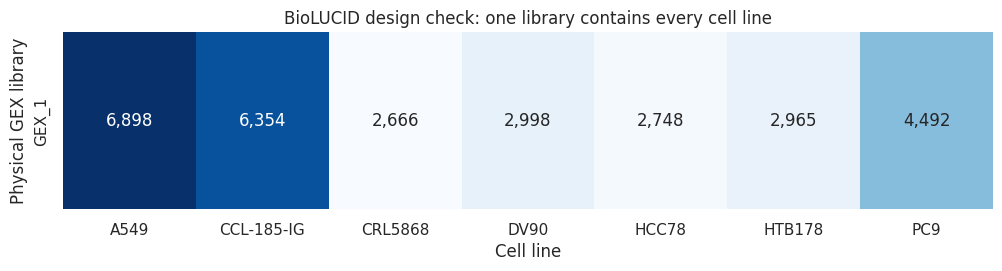

In [7]:
biolucid_applicability = pd.DataFrame(
    {
        "criterion": [
            "Physical GEX libraries",
            "Independent batch key",
            "Cell-type replication across batches",
            "BioLUCID status",
        ],
        "result": [
            "1 (GEX_1)",
            "None",
            "Not estimable",
            "Not run: batch effect is not identifiable",
        ],
    }
)
display(biolucid_applicability)

design_counts = (
    adata.obs.groupby("cell_line", observed=True).size()
    .reindex(cell_line_order)
    .to_frame().T
)
design_counts.index = ["GEX_1"]
fig, ax = plt.subplots(figsize=(12, 2.3))
sns.heatmap(
    design_counts, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax
)
ax.set(xlabel="Cell line", ylabel="Physical GEX library")
ax.set_title("BioLUCID design check: one library contains every cell line")
plt.show()

## TIDYI analysis by cell line

The TIDYI model is trained from TIDYI's bundled human SS3 and 10x reference data, restricted to genes shared with this dataset. The Arigoni cells are inference data, not training labels. Every cell line has more than 100 cells after minimal QC.

In [8]:
MIN_CELLS_PER_TIDYI_GROUP = 100
tidyi_group_counts = (
    adata.obs.groupby("cell_line", observed=True).size()
    .reindex(cell_line_order)
    .rename("n_cells")
    .reset_index()
)
assert tidyi_group_counts["n_cells"].gt(MIN_CELLS_PER_TIDYI_GROUP).all()
display(tidyi_group_counts)

tidyi_model = tidy_rates(gene_list=adata.var_names.tolist())
tidyi_model.genes = sorted(tidyi_model.genes)
tidyi_model.dat_ss3 = tidyi_model.dat_ss3[:, tidyi_model.genes].copy()
tidyi_model.dat_10x = tidyi_model.dat_10x[:, tidyi_model.genes].copy()
with threadpool_limits(limits=1):
    tidyi_model.train_death_rates(plot=False)
    with np.errstate(over="ignore"):
        tidyi_model.optimize_pathway_to_division_rate(plot=False)

,cell_line,n_cells
0,A549,6898
1,CCL-185-IG,6354
2,CRL5868,2666
3,DV90,2998
4,HCC78,2748
5,HTB178,2965
6,PC9,4492


Number of genes used for analysis:  20934
Best number of genes: 92
Best accuracy: 0.7091787439613526


adata.X seems to be already log-transformed.


Proportionality factor death: 0.8120138548835772


adata.X seems to be already log-transformed.


Only  71  genes out of  74  were found in the dataset
Proportionality factor division: 0.5044452661815261


In [9]:
tidyi_rows = []
tidyi_cell_dfs = []

for cell_line in cell_line_order:
    group_adata = adata[adata.obs["cell_line"].eq(cell_line)].copy()
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", message="Modifying `X` on a view results in data being overridden"
        )
        warnings.filterwarnings(
            "ignore", message="Received a view of an AnnData. Making a copy."
        )
        death_rate, dying_fraction, death_prediction, death_probability = (
            tidyi_model.infer_death_rate(group_adata)
        )
        proliferation_rate, proliferating_fraction, _ = (
            tidyi_model.infer_division_rate(group_adata)
        )
    death_prediction = np.asarray(death_prediction, dtype=int).ravel()
    death_probability = np.asarray(death_probability, dtype=float).ravel()

    tidyi_rows.append(
        {
            "cell_line": cell_line,
            "sample_id": group_adata.obs["sample_id"].iloc[0],
            "n_cells": group_adata.n_obs,
            "death_rate": float(death_rate),
            "proliferation_rate": float(proliferation_rate),
            "dying_fraction": float(dying_fraction),
            "proliferating_fraction": float(proliferating_fraction),
            "n_predicted_dying": int(death_prediction.sum()),
            "P_death_median": float(np.median(death_probability)),
            "P_death_q95": float(np.quantile(death_probability, 0.95)),
            "P_death_max": float(death_probability.max()),
        }
    )
    tidyi_cell_dfs.append(
        pd.DataFrame(
            {
                "cell_line": cell_line,
                "P_death": death_probability,
                "predicted_dying": death_prediction,
                "total_counts": group_adata.obs["total_counts"].to_numpy(),
                "n_genes_by_counts": group_adata.obs["n_genes_by_counts"].to_numpy(),
                "pct_counts_mt": group_adata.obs["pct_counts_mt"].to_numpy(),
            },
            index=group_adata.obs_names,
        )
    )

tidyi_results_df = pd.DataFrame(tidyi_rows)
tidyi_cell_df = pd.concat(tidyi_cell_dfs)
tidyi_results_df.to_csv(OUTPUT_DIR / "tidyi_results_df.csv", index=False)
tidyi_cell_df.to_csv(OUTPUT_DIR / "tidyi_cell_df.csv", index_label="barcode")
display(tidyi_results_df)

,cell_line,sample_id,n_cells,death_rate,proliferation_rate,dying_fraction,proliferating_fraction,n_predicted_dying,P_death_median,P_death_q95,P_death_max
0,A549,A549,6898,0.005180,0.018184,0.006379,0.036048,44,0.052518,0.227653,0.977284
1,CCL-185-IG,CCL-185-IG,6354,0.005495,0.019940,0.006767,0.039529,43,0.042249,0.203760,0.866624
2,CRL5868,CRL5868,2666,0.076145,0.003198,0.093773,0.006340,250,0.051928,0.603761,0.928903
3,DV90,DV90,2998,0.008938,0.008481,0.011007,0.016812,33,0.035949,0.234504,0.834998
4,HCC78,HCC78,2748,0.002955,0.016896,0.003639,0.033494,10,0.030929,0.149369,0.759576
5,HTB178,HTB178,2965,0.000822,0.013741,0.001012,0.027239,3,0.023153,0.114493,0.873793
6,PC9,PC9,4492,0.003435,0.027109,0.004230,0.053739,19,0.043402,0.169931,0.841936


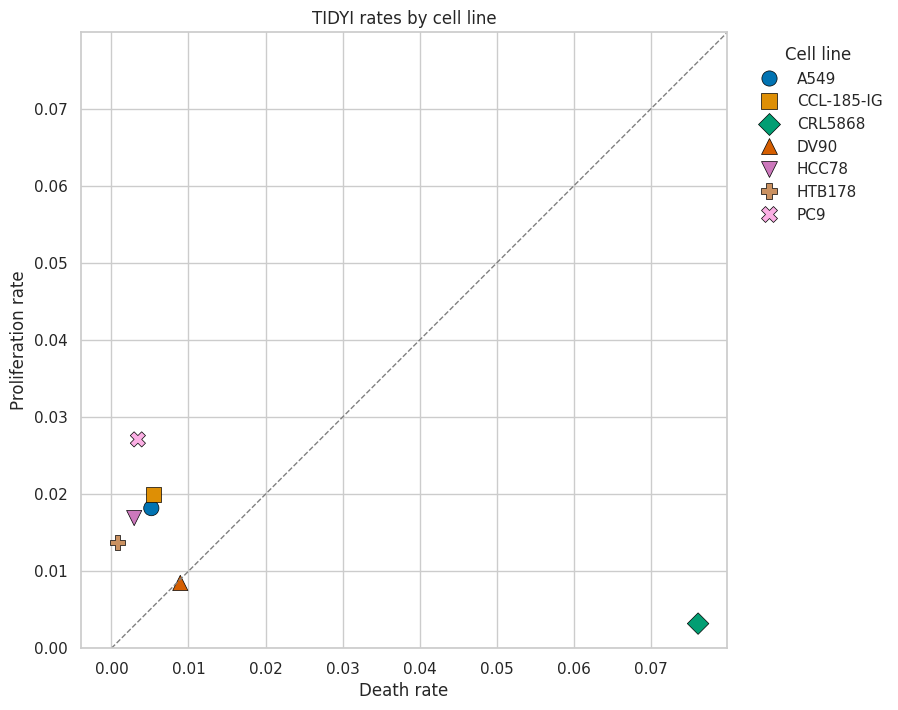

In [10]:
cell_line_markers = dict(
    zip(cell_line_order, ["o", "s", "D", "^", "v", "P", "X"])
)
fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(
    data=tidyi_results_df,
    x="death_rate", y="proliferation_rate",
    hue="cell_line", hue_order=cell_line_order,
    style="cell_line", style_order=cell_line_order,
    palette=cell_line_palette, markers=cell_line_markers, s=120,
    edgecolor="black", linewidth=0.5, ax=ax,
)
rate_max = max(
    0.01,
    1.05 * tidyi_results_df[["death_rate", "proliferation_rate"]].to_numpy().max(),
)
ax.plot([0, rate_max], [0, rate_max], "--", color="gray", linewidth=1)
x_padding = 0.05 * rate_max
ax.set_xlim(-x_padding, rate_max)
ax.set_ylim(0, rate_max)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Death rate")
ax.set_ylabel("Proliferation rate")
ax.set_title("TIDYI rates by cell line")
ax.legend(title="Cell line", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.show()

## Per-cell TIDYI death-probability diagnostics

A group-level death rate can be exactly zero even when individual probabilities are nonzero. These panels expose the full classifier output and its relationship to sequencing depth, detected genes, and mitochondrial fraction.

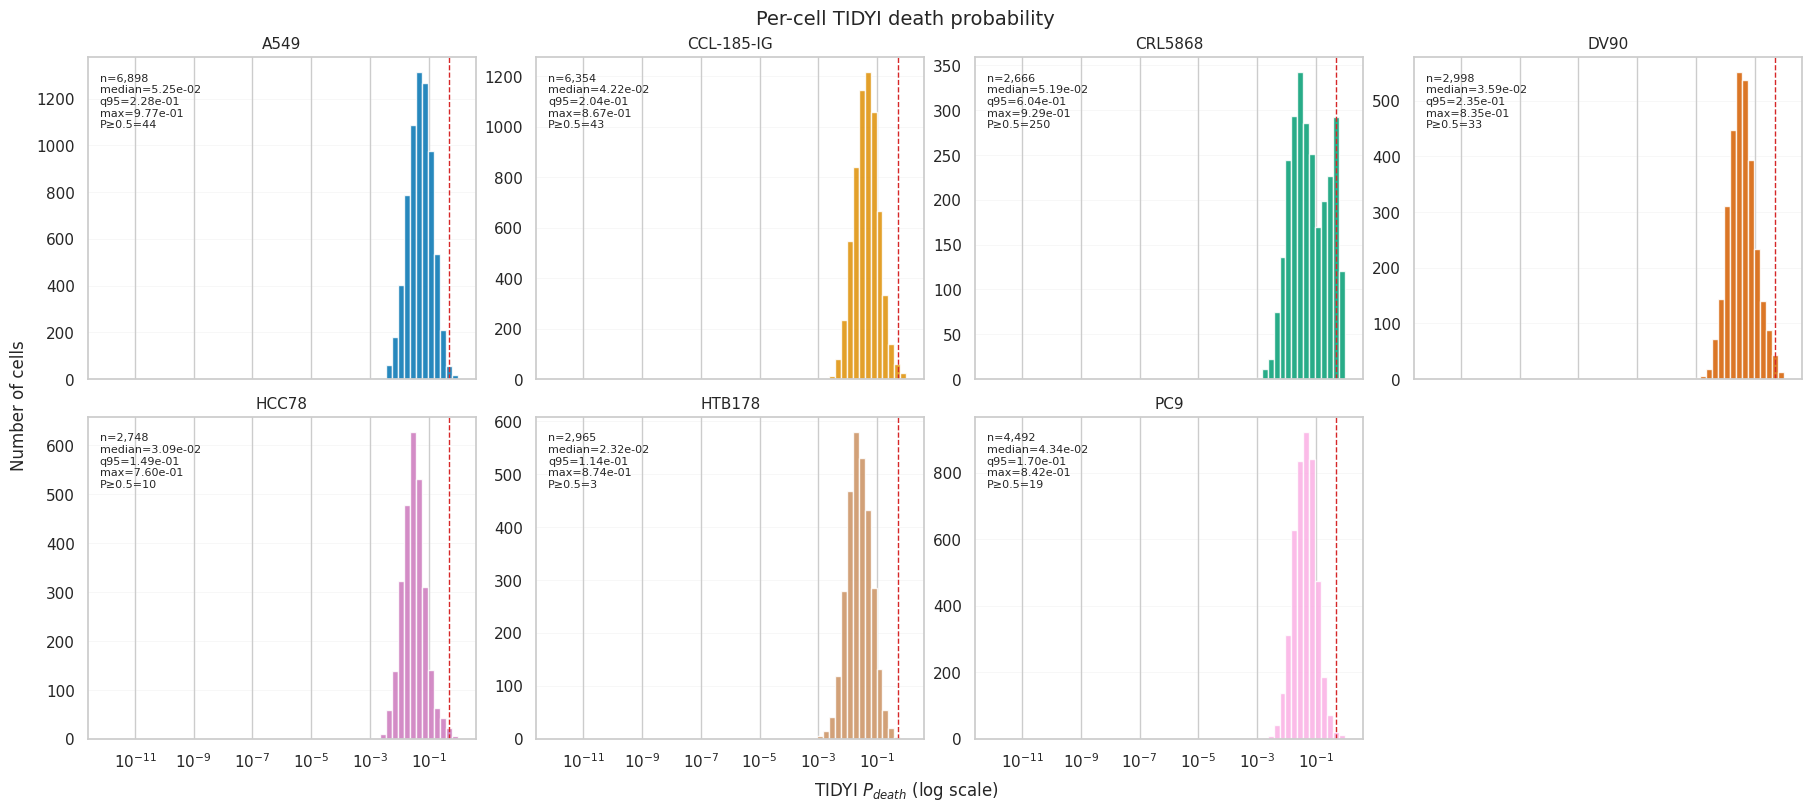

In [11]:
probability_bins = np.geomspace(1e-12, 1, 60)
fig, axes = plt.subplots(
    2, 4, figsize=(18, 8), sharex=True, constrained_layout=True
)
for ax, cell_line in zip(axes.flat, cell_line_order):
    probability = tidyi_cell_df.loc[
        tidyi_cell_df["cell_line"].eq(cell_line), "P_death"
    ].to_numpy()
    ax.hist(
        np.clip(probability, 1e-12, 1), bins=probability_bins,
        color=cell_line_palette[cell_line], alpha=0.85,
    )
    ax.axvline(0.5, color="#D62728", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(cell_line, fontsize=11)
    ax.text(
        0.03, 0.95,
        f"n={len(probability):,}\nmedian={np.median(probability):.2e}\n"
        f"q95={np.quantile(probability, 0.95):.2e}\nmax={probability.max():.2e}\n"
        f"P≥0.5={(probability >= 0.5).sum():,}",
        transform=ax.transAxes, va="top", fontsize=8,
    )
    ax.grid(True, axis="y", alpha=0.2, linewidth=0.5)

axes.flat[-1].set_visible(False)
fig.supxlabel(r"TIDYI $P_{death}$ (log scale)", fontsize=12)
fig.supylabel("Number of cells", fontsize=12)
fig.suptitle("Per-cell TIDYI death probability", fontsize=14)
plt.show()

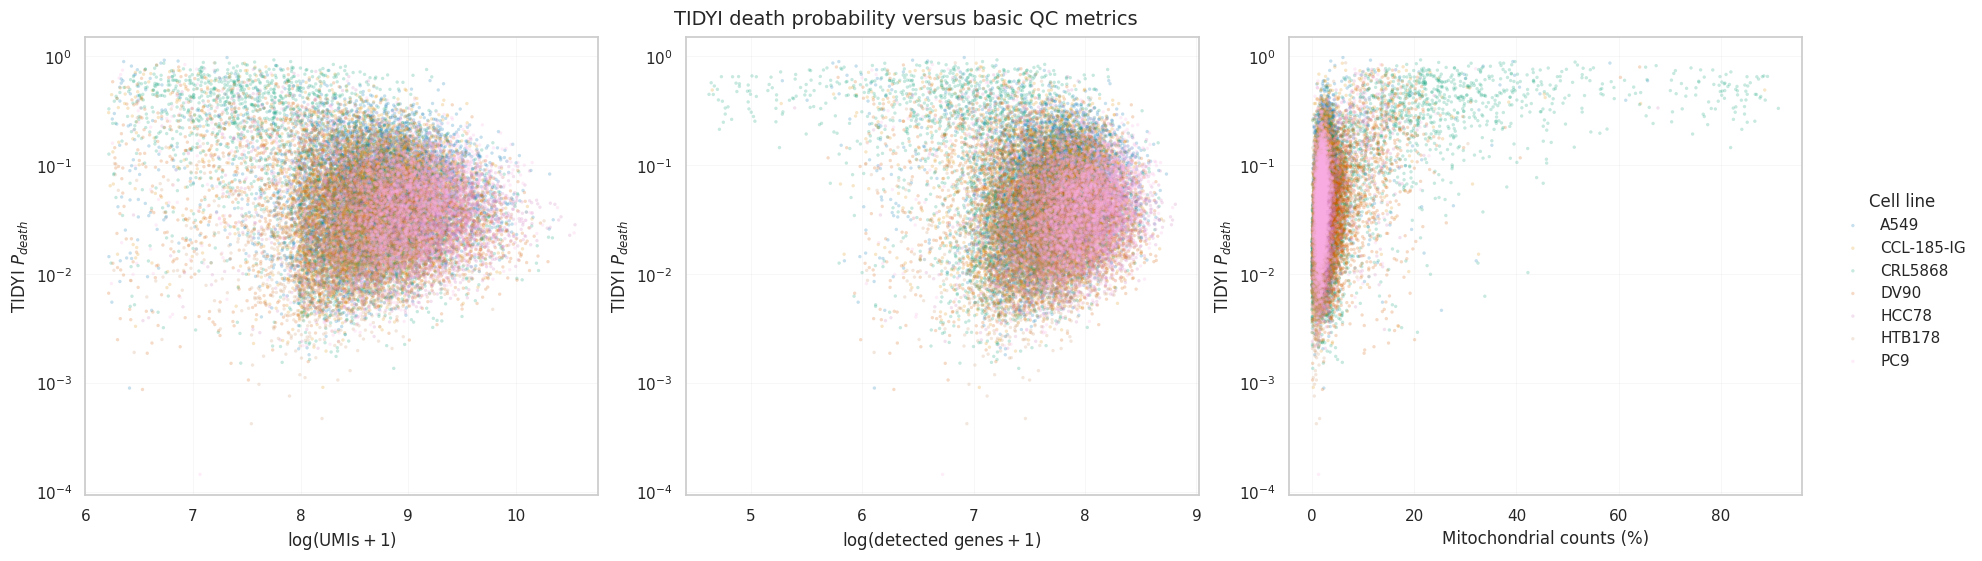

In [12]:
diagnostic_df = tidyi_cell_df.copy()
diagnostic_df["log1p_UMIs"] = np.log1p(diagnostic_df["total_counts"])
diagnostic_df["log1p_genes"] = np.log1p(diagnostic_df["n_genes_by_counts"])
diagnostic_df["P_death_plot"] = np.clip(diagnostic_df["P_death"], 1e-12, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
x_specs = [
    ("log1p_UMIs", r"$\log(\mathrm{UMIs}+1)$"),
    ("log1p_genes", r"$\log(\mathrm{detected\ genes}+1)$"),
    ("pct_counts_mt", "Mitochondrial counts (%)"),
]
for ax, (x, xlabel) in zip(axes, x_specs):
    for cell_line in cell_line_order:
        cell_line_df = diagnostic_df[diagnostic_df["cell_line"].eq(cell_line)]
        ax.scatter(
            cell_line_df[x], cell_line_df["P_death_plot"],
            s=6, alpha=0.22, color=cell_line_palette[cell_line],
            edgecolors="none", rasterized=True, label=cell_line,
        )
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"TIDYI $P_{death}$")
    ax.grid(True, alpha=0.2, linewidth=0.5)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles, labels, title="Cell line",
    bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False,
)
fig.suptitle("TIDYI death probability versus basic QC metrics", fontsize=14)
plt.show()